In [1]:
import os
import pandas as pd
import numpy as np
from transformers import AutoTokenizer, AutoModel
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

OUTPUT_DIR = "hasil_clustering"
os.makedirs(OUTPUT_DIR, exist_ok=True)
print("Setup selesai. Output folder:", os.path.abspath(OUTPUT_DIR))

C:\Users\andika\AppData\Roaming\Python\Python314\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Setup selesai. Output folder: c:\Users\andika\Projects\clustering-judul-skripsi\hasil_clustering


In [2]:
import sys
import torch
print("Python:", sys.executable)
print("Torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())


Python: c:\Program Files\Python314\python.exe
Torch: 2.10.0+cu126
CUDA available: True


In [3]:
df = pd.read_csv("dataset_titles.csv")
print(f"Dataset: {df.shape[0]} baris, {df.shape[1]} kolom")
print("Kolom:", df.columns.tolist())
df.head(3)

Dataset: 792 baris, 9 kolom
Kolom: ['id', 'title', 'clean_title', 'category', 'year', 'author', 'advisor', 'url', 'abstract_snippet']


,id,title,clean_title,category,year,author,advisor,url,abstract_snippet
0,1,Alarm Limitasi Pengunjung untuk Ruang Umum Ter...,alarm limitasi pengunjung untuk ruang umum ter...,Teknik Informatika,2021,Angelica Kirana Sandra Dewi,"Martin C.T. Manullang, S.T., M.T.",https://repo.itera.ac.id/depan/submission/SB21...,Dengan mulai kembali pulihnya perekenomian di ...
1,2,ALAT DETEKSI DAN PENGUSIRAN HAMA TIKUS DAN BUR...,alat deteksi dan pengusiran hama tikus dan bur...,Teknik Informatika,2021,Indri Wulan Dari,"Meida Cahyo Untoro, S.Kom.,M.Kom.",https://repo.itera.ac.id/depan/submission/SB22...,Alat Deteksi dan Pengusiran Hama Tikus dan Bur...
2,3,Alat Monitoring Tanah dan Pengusir Hama Otomat...,alat monitoring tanah dan pengusir hama otomat...,Teknik Informatika,2021,Leo Viranda Millennium,"Meida Cahyo Untoro, S.Kom., M.Kom.",https://repo.itera.ac.id/depan/submission/SB21...,Padi dalam pertumbuhannya memerlukan kondisi l...


In [4]:
# Gabungkan judul + abstrak sebagai input teks ke IndoBERT
def prepare_text(row):
    title = str(row['title']) if pd.notna(row['title']) else ''
    abstract = str(row['abstract_snippet']) if pd.notna(row['abstract_snippet']) else ''
    return (title + ' ' + abstract).strip()

df['text'] = df.apply(prepare_text, axis=1)
texts = df['text'].tolist()

print(f"Jumlah teks: {len(texts)}")
print("Contoh teks pertama:")
print(texts[0][:300])

Jumlah teks: 792
Contoh teks pertama:
Alarm Limitasi Pengunjung untuk Ruang Umum Tertutup Berbasis Crowd Counting Dengan mulai kembali pulihnya perekenomian di masa pandemik Covid-19 ini, aktifitas ekonomi kini kembali berjalan lagi. Sektor bisnis dan perdagangan pun mulai dibuka kembali. Dengan dibukanya sektor tersebut, dikhawatirkan 


In [5]:

MODEL_NAME = "indobenchmark/indobert-base-p1"
device = "cuda"
print(f"Device: {device}")

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
bert_model = AutoModel.from_pretrained(MODEL_NAME)
bert_model = bert_model.to(device)
bert_model.eval()

print(f"Model '{MODEL_NAME}' berhasil dimuat.")


Device: cuda


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 55404.35it/s]


Model 'indobenchmark/indobert-base-p1' berhasil dimuat.


In [6]:
# Fungsi mean pooling: rata-rata token embeddings (abaikan padding)
def mean_pooling(model_output, attention_mask):
    token_embeddings = model_output.last_hidden_state
    mask_expanded = attention_mask.unsqueeze(-1).expand_as(token_embeddings).float()
    return torch.sum(token_embeddings * mask_expanded, 1) / torch.clamp(mask_expanded.sum(1), min=1e-9)

def get_embeddings(texts, batch_size=16):
    all_embeddings = []
    total_batches = (len(texts) + batch_size - 1) // batch_size
    for i in range(0, len(texts), batch_size):
        batch = texts[i : i + batch_size]
        encoded = tokenizer(
            batch, padding=True, truncation=True,
            max_length=128, return_tensors="pt"
        )
        encoded = {k: v.to(device) for k, v in encoded.items()}
        with torch.no_grad():
            output = bert_model(**encoded)
        embeddings = mean_pooling(output, encoded["attention_mask"])
        all_embeddings.append(embeddings.cpu().numpy())
        batch_num = i // batch_size + 1
        if batch_num % 10 == 0 or batch_num == total_batches:
            print(f"  Batch {batch_num}/{total_batches} selesai")
    return np.vstack(all_embeddings)

print("Membuat embeddings dengan IndoBERT...")
embeddings = get_embeddings(texts)
print(f"\nShape embeddings: {embeddings.shape}")

np.save(os.path.join(OUTPUT_DIR, "embeddings.npy"), embeddings)
print(f"Embeddings disimpan ke {OUTPUT_DIR}/embeddings.npy")

Membuat embeddings dengan IndoBERT...
  Batch 10/50 selesai
  Batch 20/50 selesai
  Batch 30/50 selesai
  Batch 40/50 selesai
  Batch 50/50 selesai

Shape embeddings: (792, 768)
Embeddings disimpan ke hasil_clustering/embeddings.npy


In [7]:
# Reduksi dimensi dengan PCA sebelum clustering (mengatasi curse of dimensionality)
N_COMPONENTS = 50

pca_pre = PCA(n_components=N_COMPONENTS, random_state=42)
embeddings_pca = pca_pre.fit_transform(embeddings)

variance_explained = pca_pre.explained_variance_ratio_.sum() * 100
print(f"PCA: {embeddings.shape[1]}D → {N_COMPONENTS}D")
print(f"Variance explained: {variance_explained:.1f}%")
print(f"Shape embeddings_pca: {embeddings_pca.shape}")


PCA: 768D → 50D
Variance explained: 70.1%
Shape embeddings_pca: (792, 50)


Mencari K optimal pada 50D PCA embeddings...
  K= 2 | inertia=33,489 | silhouette=0.0840
  K= 3 | inertia=32,199 | silhouette=0.0811
  K= 4 | inertia=31,208 | silhouette=0.0524
  K= 5 | inertia=30,296 | silhouette=0.0567
  K= 6 | inertia=29,576 | silhouette=0.0616
  K= 7 | inertia=28,960 | silhouette=0.0575
  K= 8 | inertia=28,474 | silhouette=0.0616
  K= 9 | inertia=27,999 | silhouette=0.0605
  K=10 | inertia=27,559 | silhouette=0.0569
  K=11 | inertia=27,259 | silhouette=0.0568
  K=12 | inertia=26,835 | silhouette=0.0628
  K=13 | inertia=26,610 | silhouette=0.0556
  K=14 | inertia=26,305 | silhouette=0.0581
  K=15 | inertia=25,958 | silhouette=0.0586

K terbaik otomatis (silhouette): 2
K yang digunakan               : 8


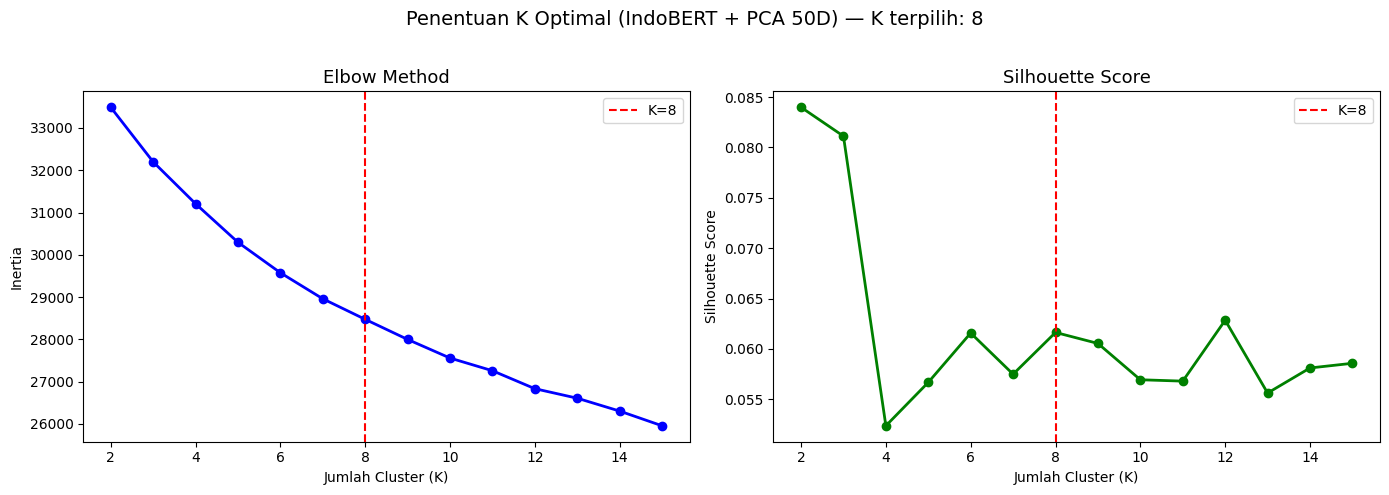

Plot disimpan ke hasil_clustering/elbow_silhouette.png


In [8]:
# Cari K optimal menggunakan Elbow Method + Silhouette Score (pakai embeddings_pca)
K_MIN, K_MAX = 2, 15

# MANUAL_K: Set angka tertentu untuk override otomatis silhouette.
#   - Isi None  → pakai K terbaik dari silhouette score
#   - Isi angka → pakai K itu (misal 6, 8, 10)
MANUAL_K = 8

inertias = []
sil_scores = []
ks = list(range(K_MIN, K_MAX + 1))

print(f"Mencari K optimal pada {N_COMPONENTS}D PCA embeddings...")
for k in ks:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels_k = km.fit_predict(embeddings_pca)
    inertias.append(km.inertia_)
    sil = silhouette_score(embeddings_pca, labels_k)
    sil_scores.append(sil)
    print(f"  K={k:2d} | inertia={km.inertia_:,.0f} | silhouette={sil:.4f}")

best_k_auto = ks[np.argmax(sil_scores)]
best_k = MANUAL_K if MANUAL_K is not None else best_k_auto
print(f"\nK terbaik otomatis (silhouette): {best_k_auto}")
print(f"K yang digunakan               : {best_k}")

# Plot Elbow + Silhouette
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(ks, inertias, "bo-", linewidth=2, markersize=6)
ax1.axvline(x=best_k, color="r", linestyle="--", label=f"K={best_k}")
ax1.set_title("Elbow Method", fontsize=13)
ax1.set_xlabel("Jumlah Cluster (K)")
ax1.set_ylabel("Inertia")
ax1.legend()

ax2.plot(ks, sil_scores, "go-", linewidth=2, markersize=6)
ax2.axvline(x=best_k, color="r", linestyle="--", label=f"K={best_k}")
ax2.set_title("Silhouette Score", fontsize=13)
ax2.set_xlabel("Jumlah Cluster (K)")
ax2.set_ylabel("Silhouette Score")
ax2.legend()

plt.suptitle(f"Penentuan K Optimal (IndoBERT + PCA {N_COMPONENTS}D) — K terpilih: {best_k}", fontsize=14)
fig.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig(os.path.join(OUTPUT_DIR, "elbow_silhouette.png"), dpi=150, bbox_inches="tight")
plt.show()
print(f"Plot disimpan ke {OUTPUT_DIR}/elbow_silhouette.png")


In [9]:
print(f"Menjalankan K-Means dengan K={best_k} pada {N_COMPONENTS}D PCA embeddings...")
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(embeddings_pca)

df["cluster"] = cluster_labels

print("\nDistribusi cluster:")
dist = df["cluster"].value_counts().sort_index()
for cid, count in dist.items():
    print(f"  Cluster {cid}: {count} judul")


Menjalankan K-Means dengan K=8 pada 50D PCA embeddings...

Distribusi cluster:
  Cluster 0: 161 judul
  Cluster 1: 105 judul
  Cluster 2: 74 judul
  Cluster 3: 105 judul
  Cluster 4: 123 judul
  Cluster 5: 110 judul
  Cluster 6: 52 judul
  Cluster 7: 62 judul


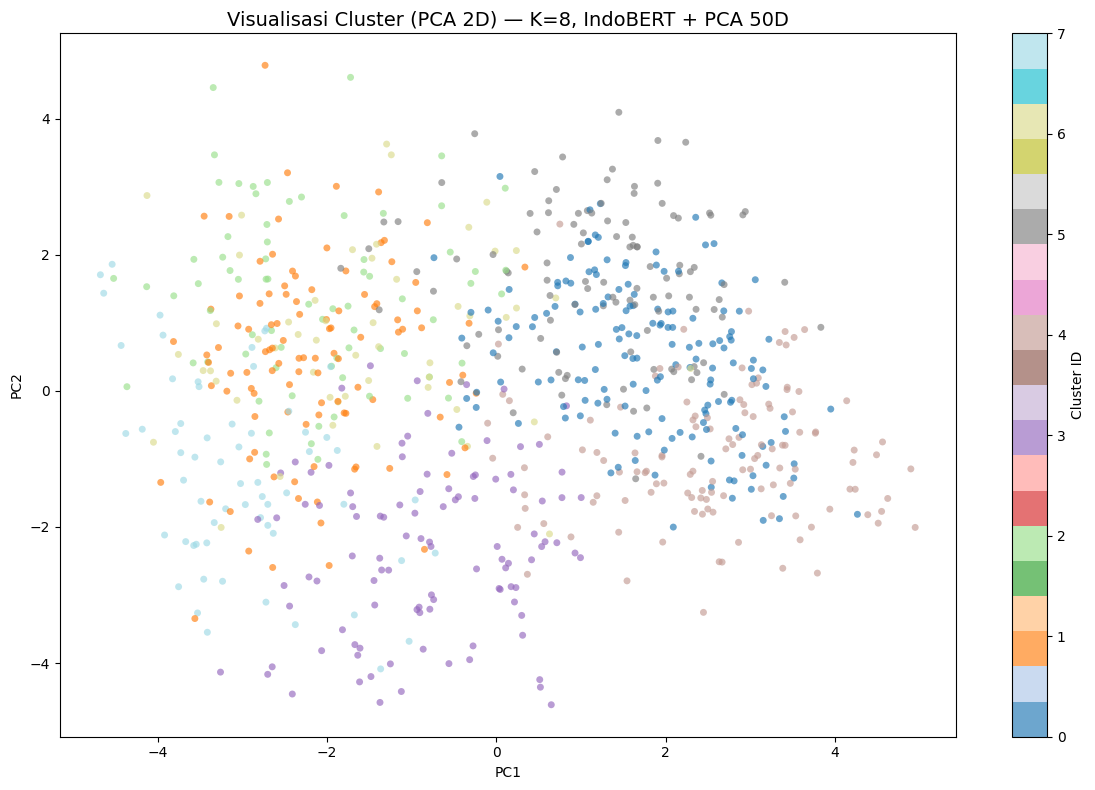

Visualisasi disimpan ke hasil_clustering/cluster_visualisasi.png


In [10]:
pca_viz = PCA(n_components=2, random_state=42)
emb_2d = pca_viz.fit_transform(embeddings_pca)

plt.figure(figsize=(12, 8))
scatter = plt.scatter(
    emb_2d[:, 0], emb_2d[:, 1],
    c=cluster_labels, cmap="tab20",
    alpha=0.65, s=25, linewidths=0
)
plt.colorbar(scatter, label="Cluster ID")
plt.title(f"Visualisasi Cluster (PCA 2D) — K={best_k}, IndoBERT + PCA {N_COMPONENTS}D", fontsize=14)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "cluster_visualisasi.png"), dpi=150, bbox_inches="tight")
plt.show()
print(f"Visualisasi disimpan ke {OUTPUT_DIR}/cluster_visualisasi.png")


In [11]:
result_df = df[["id", "title", "clean_title", "category", "year", "author", "abstract_snippet", "cluster"]].copy()

all_csv_path = os.path.join(OUTPUT_DIR, "hasil_clustering_all.csv")
result_df.to_csv(all_csv_path, index=False)
print(f"Semua hasil: {all_csv_path}")

print("\nFile per cluster:")
for cid in sorted(result_df["cluster"].unique()):
    cluster_df = result_df[result_df["cluster"] == cid].copy()
    out_path = os.path.join(OUTPUT_DIR, f"cluster_{cid}.csv")
    cluster_df.to_csv(out_path, index=False)
    print(f"  Cluster {cid:2d} ({len(cluster_df):4d} judul): {out_path}")

Semua hasil: hasil_clustering\hasil_clustering_all.csv

File per cluster:
  Cluster  0 ( 161 judul): hasil_clustering\cluster_0.csv
  Cluster  1 ( 105 judul): hasil_clustering\cluster_1.csv
  Cluster  2 (  74 judul): hasil_clustering\cluster_2.csv
  Cluster  3 ( 105 judul): hasil_clustering\cluster_3.csv
  Cluster  4 ( 123 judul): hasil_clustering\cluster_4.csv
  Cluster  5 ( 110 judul): hasil_clustering\cluster_5.csv
  Cluster  6 (  52 judul): hasil_clustering\cluster_6.csv
  Cluster  7 (  62 judul): hasil_clustering\cluster_7.csv
